In [1]:
import json
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def get_file_size(suite_name):
    if "json" in suite_name.lower():
        return JSON_PERSON_FILE_SIZE
    return CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name):
    with open(filepath) as f:
        data = json.load(f)
    file_size = get_file_size(suite_name)
    rows = []
    for r in data:
        if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
            continue
        started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
        stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
        exec_time = (stopped - started).total_seconds()
        query = shorten_query(r["query"].strip())
        rows.append({
            "suite": suite_name,
            "query": query,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776208273.json", "CSV baseline")
rows += load_suite("results/optimized_results_1776211020.json", "CSV optimized")
rows += load_suite("results/baseline-json_results_1776213750.json", "JSON baseline")
rows += load_suite("results/optimized-json_results_1776216083.json", "JSON optimized")
df = pd.DataFrame(rows)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 1400
Suites: ['CSV baseline', 'CSV optimized', 'JSON baseline', 'JSON optimized']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(48), np.int64(64)]
Queries: ['SELECT extra FROM person', 'SELECT id FROM person WHERE "redmondwy" == CONCAT(city, state)', 'SELECT id FROM person WHERE CONCAT(city, state) == "redmondwy"', 'SELECT id FROM person WHERE city == "redmond"', 'SELECT id FROM person WHERE city == "redmond" AND state == "wy"']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV baseline,"SELECT id FROM person WHERE CONCAT(city, state...",2,14.248,58.964827
1,CSV baseline,"SELECT id FROM person WHERE CONCAT(city, state...",2,14.354,58.529390
2,CSV baseline,"SELECT id FROM person WHERE CONCAT(city, state...",2,14.359,58.509009
3,CSV baseline,"SELECT id FROM person WHERE CONCAT(city, state...",2,14.236,59.014531
4,CSV baseline,"SELECT id FROM person WHERE CONCAT(city, state...",2,14.304,58.733981
...,...,...,...,...,...
1395,JSON optimized,"SELECT id FROM person WHERE city == ""redmond""",64,0.849,1461.335775
1396,JSON optimized,"SELECT id FROM person WHERE city == ""redmond""",64,0.801,1548.906458
1397,JSON optimized,"SELECT id FROM person WHERE city == ""redmond""",64,0.810,1531.696387
1398,JSON optimized,"SELECT id FROM person WHERE city == ""redmond""",64,0.782,1586.539736


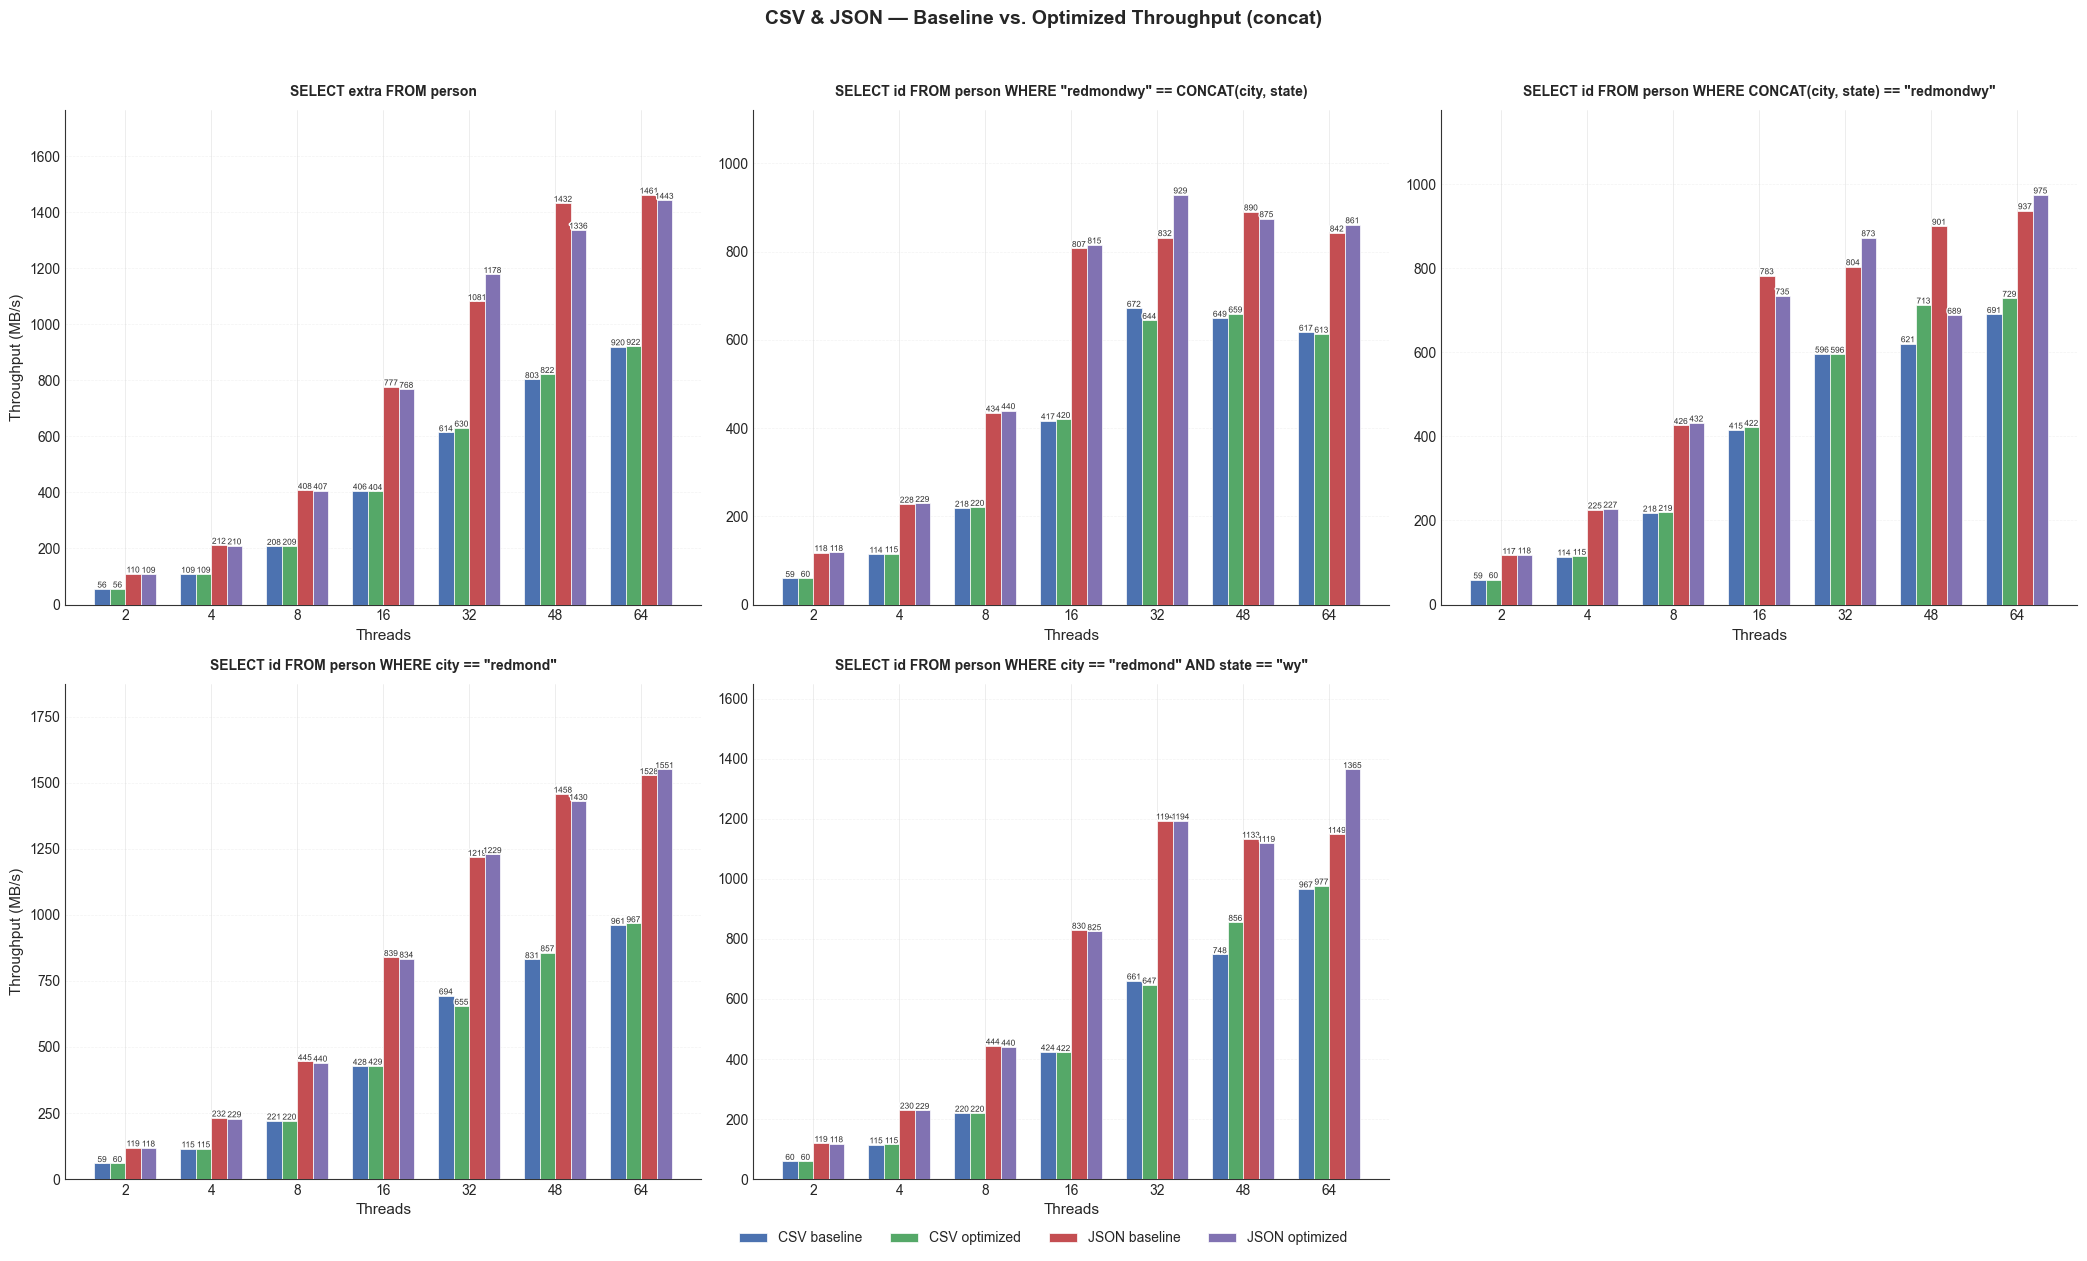

In [2]:
# Grouped bar chart: 4 suites per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                              f"{h:.0f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON \u2014 Baseline vs. Optimized Throughput (concat)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

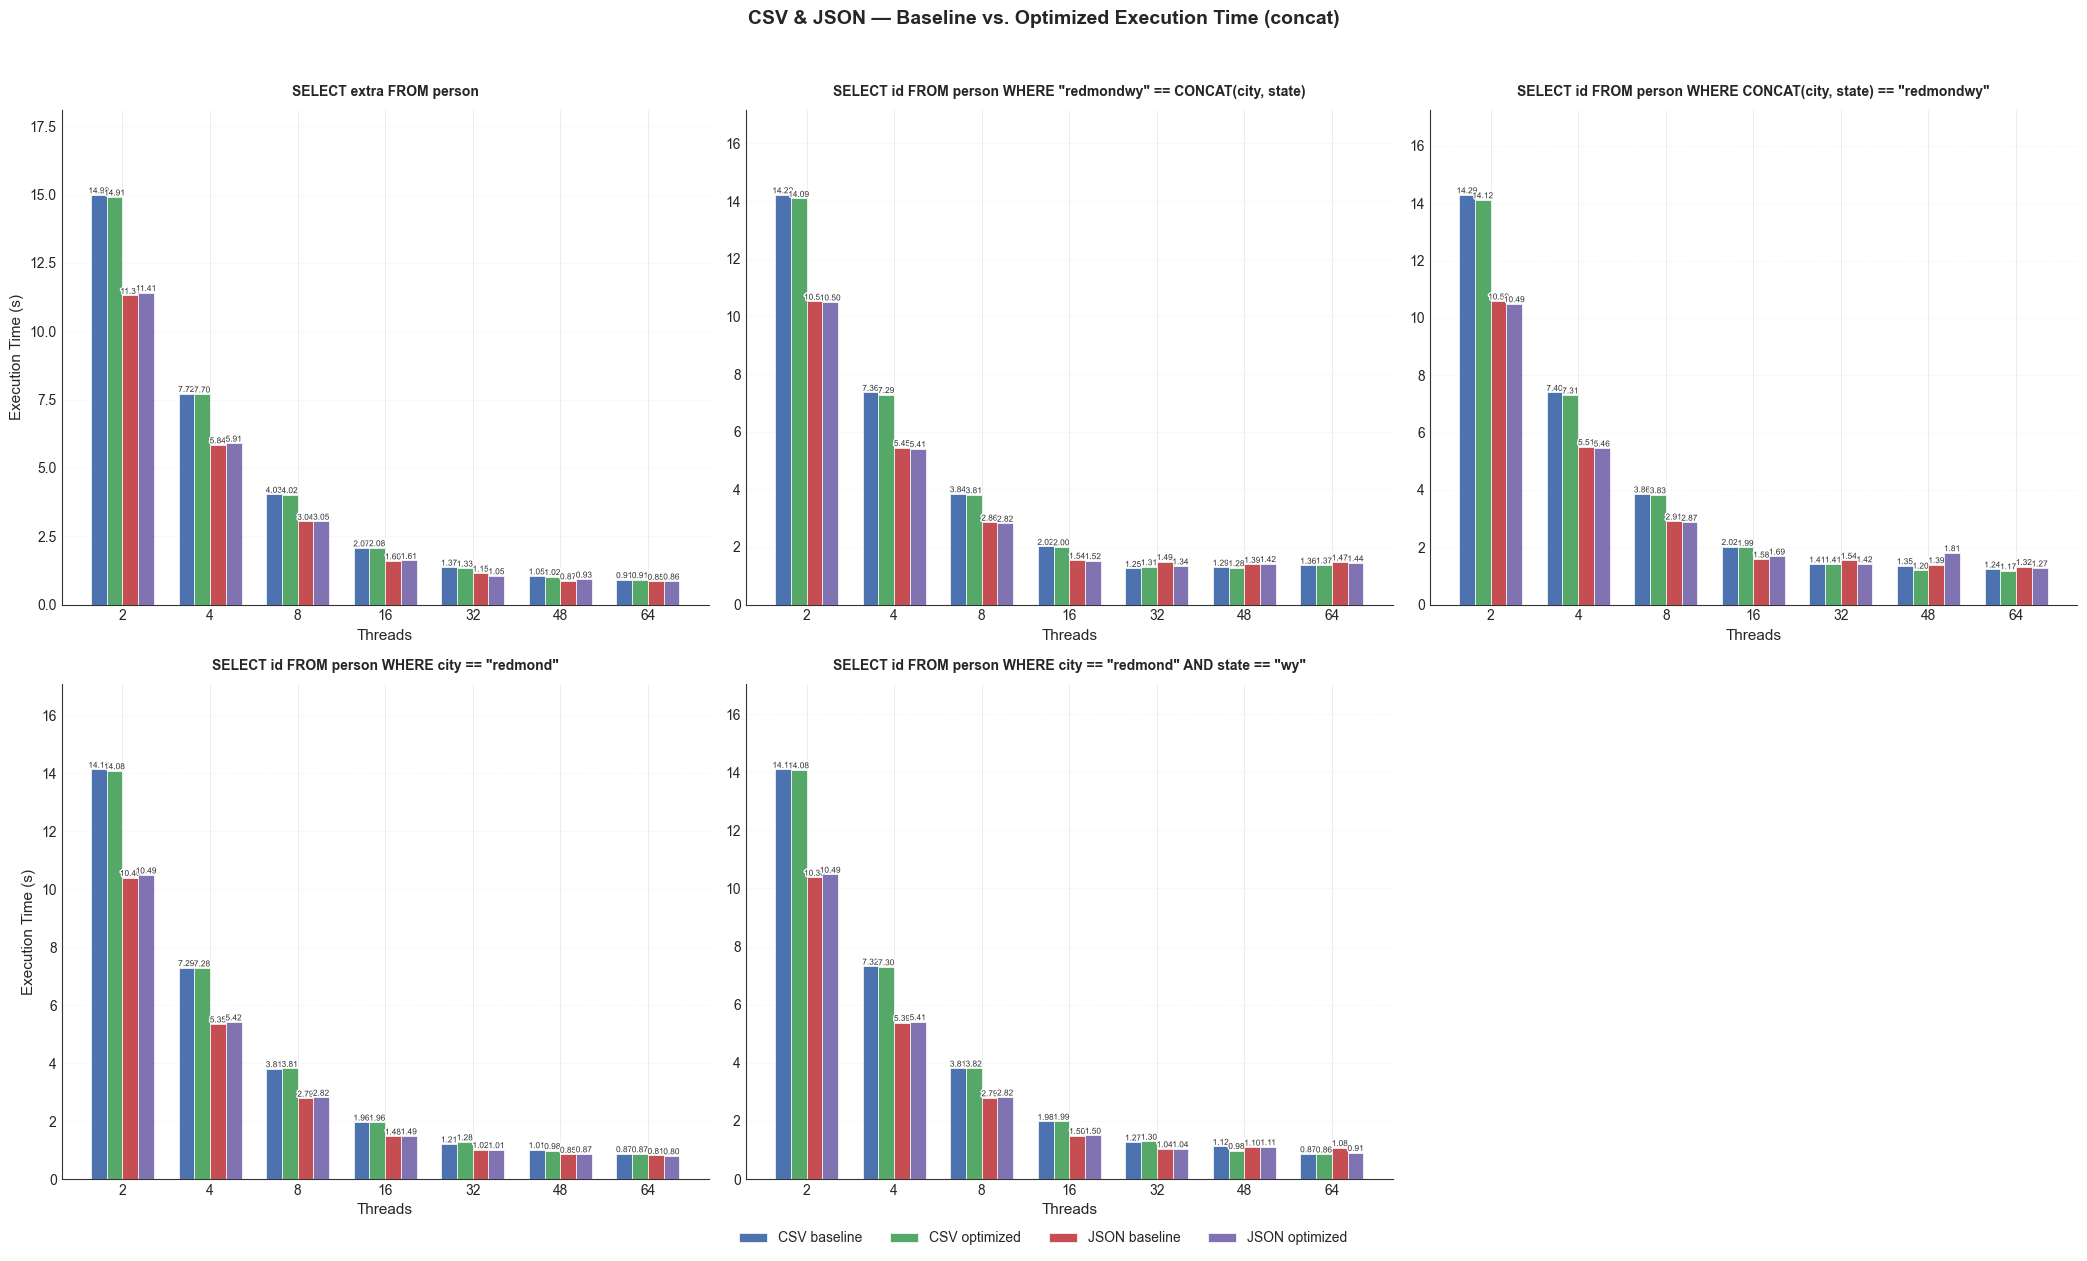

In [3]:
# Grouped bar chart: execution time per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["exec_time_s"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                              f"{h:.2f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Execution Time (s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON \u2014 Baseline vs. Optimized Execution Time (concat)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

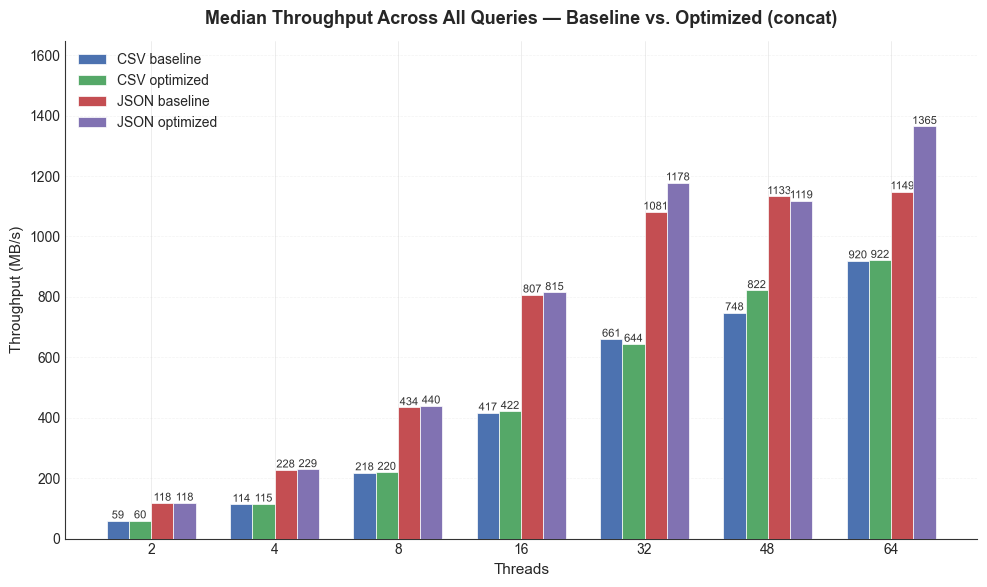

In [4]:
# Median throughput across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    if suite not in median_across.index.get_level_values("suite"):
        continue
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                          f"{h:.0f}", ha="center", va="bottom", fontsize=8,
                          color="#333333", fontweight="medium")
            txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Throughput (MB/s)", fontsize=11, fontweight="medium")
ax.set_title("Median Throughput Across All Queries \u2014 Baseline vs. Optimized (concat)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()

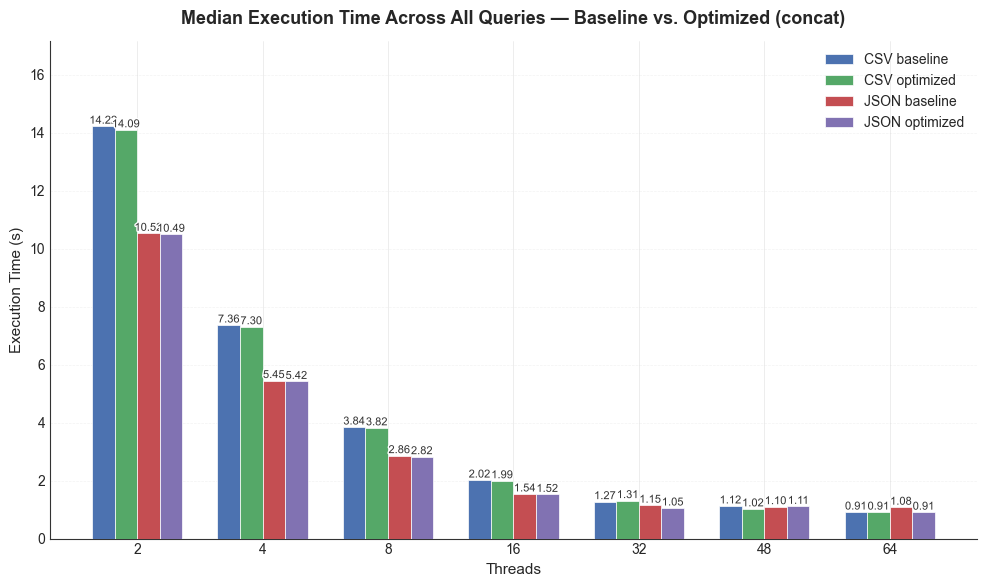

In [5]:
# Median execution time across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

median_across = (
    df.groupby(["suite", "threads", "query"])["exec_time_s"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    if suite not in median_across.index.get_level_values("suite"):
        continue
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                          f"{h:.2f}", ha="center", va="bottom", fontsize=8,
                          color="#333333", fontweight="medium")
            txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Execution Time (s)", fontsize=11, fontweight="medium")
ax.set_title("Median Execution Time Across All Queries \u2014 Baseline vs. Optimized (concat)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()

In [6]:
# Summary table: throughput (MB/s) all 4 suites
all_suites = [s for s in ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"] if s in df["suite"].unique()]
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[[s for s in all_suites if s in pivot.columns]]
if "CSV baseline" in pivot.columns and "CSV optimized" in pivot.columns:
    pivot["CSV speedup"] = pivot["CSV optimized"] / pivot["CSV baseline"]
if "JSON baseline" in pivot.columns and "JSON optimized" in pivot.columns:
    pivot["JSON speedup"] = pivot["JSON optimized"] / pivot["JSON baseline"]
pivot.round(2)

suite                                                       CSV baseline  \
query                                              threads                 
SELECT extra FROM person                           2               56.04   
                                                   4              108.81   
                                                   8              208.31   
                                                   16             405.86   
                                                   32             613.69   
                                                   48             803.19   
                                                   64             920.19   
SELECT id FROM person WHERE "redmondwy" == CONC... 2               59.09   
                                                   4              114.11   
                                                   8              218.50   
                                                   16             416.63   
                                                   32             671.62   
                                                   48             649.09   
                                                   64             617.35   
SELECT id FROM person WHERE CONCAT(city, state)... 2               58.79   
                                                   4              113.58   
                                                   8              217.85   
                                                   16             415.40   
                                                   32             596.42   
                                                   48             620.95   
                                                   64             690.59   
SELECT id FROM person WHERE city == "redmond"      2               59.46   
                                                   4              115.22   
                                                   8              220.77   
                                                   16             427.77   
                                                   32             694.33   
                                                   48             831.28   
                                                   64             961.25   
SELECT id FROM person WHERE city == "redmond" A... 2               59.59   
                                                   4              114.70   
                                                   8              220.25   
                                                   16             424.20   
                                                   32             660.75   
                                                   48             748.13   
                                                   64             967.37   

suite                                                       CSV optimized  \
query                                              threads                  
SELECT extra FROM person                           2                56.34   
                                                   4               109.06   
                                                   8               208.91   
                                                   16              404.10   
                                                   32              630.26   
                                                   48              821.65   
                                                   64              921.70   
SELECT id FROM person WHERE "redmondwy" == CONC... 2                59.61   
                                                   4               115.28   
                                                   8               220.45   
                                                   16              419.65   
                                                   32              644.16   
                                                   48              658.81   
                                